# Run first

In [1]:
import os
import pandas as pd
from scipy import stats
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec

import pyemu
import flopy

# Prior IES

## Prep (~10min)

In [2]:
run_name = 'local_run0'
o_d = f'../models/{run_name}/{run_name}'
temp_d = f'../models/{run_name}/{run_name}'
m_d = f'../models/{run_name}/pest/master_ies_prior'

In [ ]:
# observations
pr_oe_fn = os.path.join(m_d, f"{run_name}.0.obs.csv")
noise_fn = os.path.join(m_d, f"{run_name}.obs+noise.csv")

In [ ]:
# Read only the headers
headers = pd.read_csv(pr_oe_fn, nrows=0).columns.tolist()

In [4]:
# observations
pr_pe_fn = os.path.join(m_d, f"{run_name}.0.par.csv")
# Read only the headers
params_headers = pd.read_csv(pr_pe_fn, nrows=0).columns.tolist()

In [7]:
extract_kper = lambda x: int([s for s in x.split('_') if s.startswith('kper:')][0].split(':')[1])
extract_kstp = lambda x: int([s for s in x.split('_') if s.startswith('kstp:')][0].split(':')[1])
extract_i = lambda x: int([s for s in x.split('_') if s.startswith('i:')][0].split(':')[1])
extract_j = lambda x: int([s for s in x.split('_') if s.startswith('j:')][0].split(':')[1])
extract_time = lambda x: int([s for s in x.split('_') if s.startswith('time:')][0].split(':')[1])
extract_usecol = lambda x: [s for s in x.split('_') if s.startswith('usecol:')][0].split(':')[1]

## Diagnostics

## Prior data conflict check

In [ ]:
# Decide which columns you want to load
desired_cols = [col for col in headers if col.startswith('oname:budget')]

# heads
pre_oe_budget = pd.read_csv(pr_oe_fn, usecols=desired_cols)
noise = pd.read_csv(os.path.join(m_d,f"{run_name}.obs+noise.csv"), index_col=0)

In [80]:
params_headers

['real_name',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:27_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:32_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:37_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:42_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:47_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:17_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:22_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:27_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:32_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:37_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:42_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:47_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:52_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:12_j:12_zone:1',
 'pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:12_j:17_zone:1',
 'pname:n

## Heads (array)

### Prep

In [23]:
extract_kper =  lambda x: int(x.split('_')[0].split('-')[2].replace('kper', ''))
extract_kstp = lambda x: int(x.split('_')[0].split('-')[3].replace('kstp', ''))
extract_i = lambda x: int([s for s in x.split('_') if s.startswith('i:')][0].split(':')[1])
extract_j = lambda x: int([s for s in x.split('_') if s.startswith('j:')][0].split(':')[1])
extract_time = lambda x: int([s for s in x.split('_') if s.startswith('time:')][0].split(':')[1])
extract_usecol = lambda x: [s for s in x.split('_') if s.startswith('usecol:')][0].split(':')[1]

In [18]:
# Decide which columns you want to load
desired_cols = [col for col in headers if col.startswith('oname:h-')]

# heads
pre_oe_modelheads = pd.read_csv(pr_oe_fn, usecols=desired_cols)

In [24]:
input_df.head().index

Index(['oname:h-lyr1-kper1-kstp1_otype:arr_i:10_j:11_zone:1',
       'oname:h-lyr1-kper1-kstp1_otype:arr_i:10_j:12_zone:1',
       'oname:h-lyr1-kper1-kstp1_otype:arr_i:10_j:13_zone:1',
       'oname:h-lyr1-kper1-kstp1_otype:arr_i:10_j:14_zone:1',
       'oname:h-lyr1-kper1-kstp1_otype:arr_i:10_j:15_zone:1'],
      dtype='object')

In [25]:
input_df = pre_oe_modelheads.transpose()
input_df['kper'] = input_df.index.map(extract_kper)
input_df['kstp'] = input_df.index.map(extract_kstp)
input_df['i'] = input_df.index.map(extract_i)
input_df['j'] = input_df.index.map(extract_j)

In [26]:
nkper = input_df['kper'].unique()
nstp = input_df['kstp'].unique()

In [27]:
# get all the heads into an array which we can now call to plot
arrs = {}
for i in set(zip(input_df['kper'], input_df['kstp'])):
    kper, kstp = i
    idf = input_df[(input_df['kper'] == kper) & (input_df['kstp'] == kstp)]
    i_arrs = []
    for real in idf.columns[:-4]:
        arr = idf.pivot(index='i', columns='j', values=real).to_numpy()
        max_nan = 1e+30
        arr = np.where(arr == max_nan, np.nan, arr)
        i_arrs.append(arr)
    i_stack = np.stack(i_arrs)
    arrs[i] = {
        'i_stack': i_stack,
        'mean': np.mean(i_stack, axis=0),
        'min': np.min(i_stack, axis=0),
        'max': np.max(i_stack, axis=0),
        'std': np.std(i_stack, axis=0),
    }

### Stess period stats

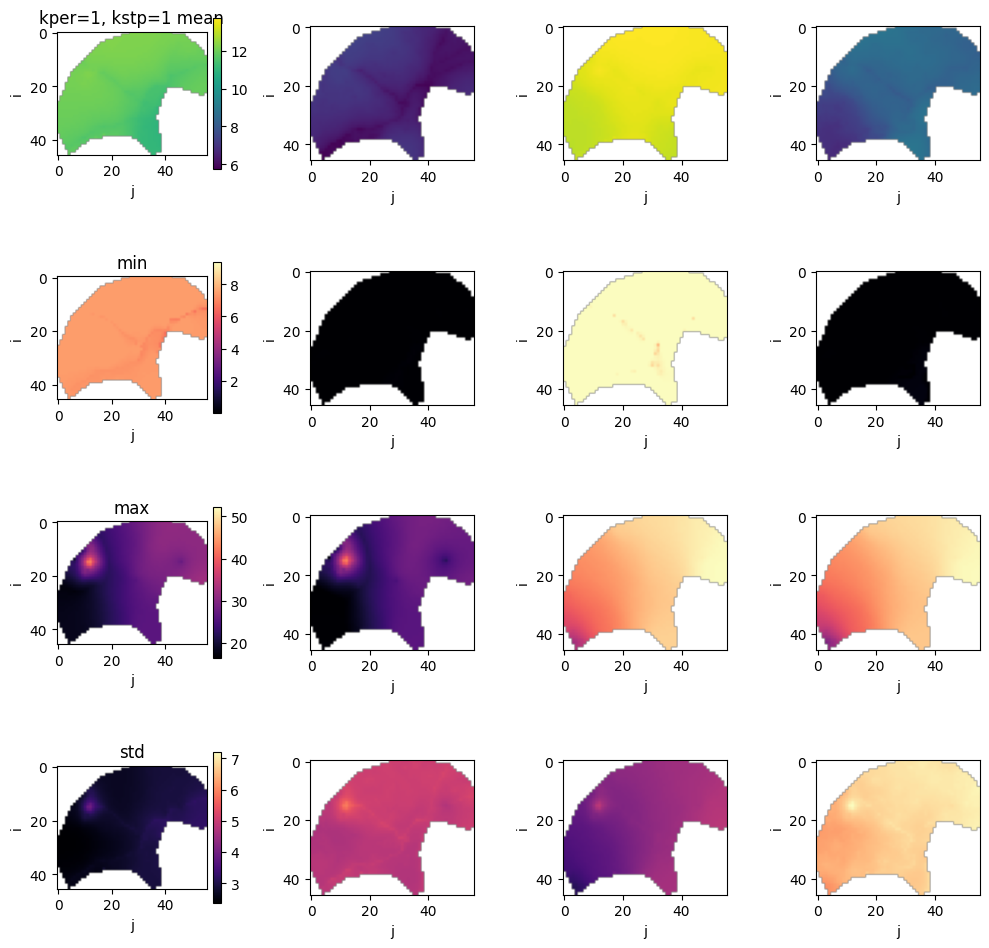

In [32]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))

# Calculate vmin/vmax for each row (stat type) across all kpers
mean_arrays = [arrs[(kper, 1)]['mean'] for kper in range(1, 5)]
min_arrays = [arrs[(kper, 1)]['min'] for kper in range(1, 5)]
max_arrays = [arrs[(kper, 1)]['max'] for kper in range(1, 5)]
std_arrays = [arrs[(kper, 1)]['std'] for kper in range(1, 5)]

# Calculate shared vmin/vmax for each row
mean_vmin, mean_vmax = np.nanmin(mean_arrays), np.nanmax(mean_arrays)
min_vmin, min_vmax = np.nanmin(min_arrays), np.nanmax(min_arrays)
max_vmin, max_vmax = np.nanmin(max_arrays), np.nanmax(max_arrays)
std_vmin, std_vmax = np.nanmin(std_arrays), np.nanmax(std_arrays)

for idx, kper in enumerate(range(1, 5)):
    key = (kper, 1)
    mean_arr = arrs[key]['mean']
    std_arr = arrs[key]['std']
    min_arr = arrs[key]['min']
    max_arr = arrs[key]['max']
    
    # Row 0: Mean
    im0 = axes[0, idx].imshow(mean_arr, cmap='viridis', vmin=mean_vmin, vmax=mean_vmax)
    
    # Row 1: Min
    im1 = axes[1, idx].imshow(min_arr, cmap='magma', vmin=min_vmin, vmax=min_vmax)

    # Row 2: Max
    im2 = axes[2, idx].imshow(max_arr, cmap='magma', vmin=max_vmin, vmax=max_vmax)

    # Row 3: Std
    im3 = axes[3, idx].imshow(std_arr, cmap='magma', vmin=std_vmin, vmax=std_vmax)

    if idx == 0:
        axes[0, idx].set_title(f'kper={kper}, kstp=1 mean')
        axes[1, idx].set_title(f'min')
        axes[2, idx].set_title(f'max')
        axes[3, idx].set_title(f'std')
        plt.colorbar(im0, ax=axes[0, idx], fraction=0.046, pad=0.04)
        plt.colorbar(im1, ax=axes[1, idx], fraction=0.046, pad=0.04)
        plt.colorbar(im2, ax=axes[2, idx], fraction=0.046, pad=0.04)
        plt.colorbar(im3, ax=axes[3, idx], fraction=0.046, pad=0.04)


for ax in axes.flat:
    ax.set_xlabel('j')
    ax.set_ylabel('i')

plt.tight_layout()
plt.show()

### Timesteps within stress period

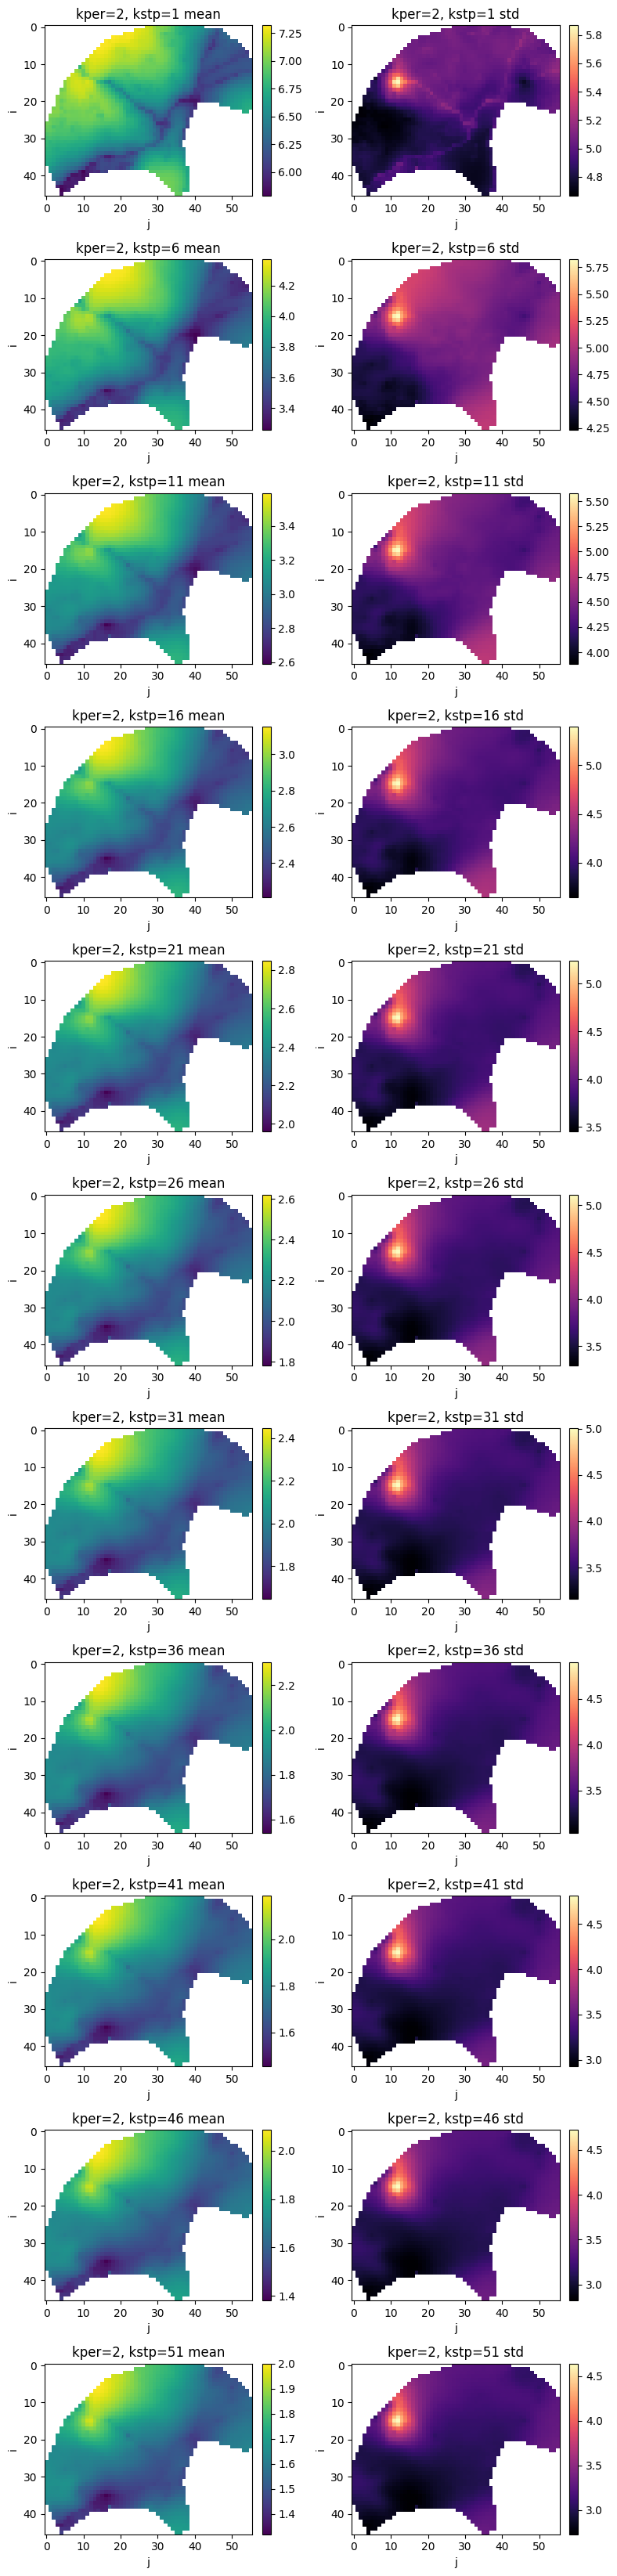

In [33]:
kper = 2
kstp_steps = range(1, nstp.max(), 5)  # every 5th kstp

fig, axes = plt.subplots(nrows=len(kstp_steps), ncols=2, figsize=(8, 3 * len(kstp_steps)))

for idx, kstp in enumerate(kstp_steps):
    key = (kper, kstp)
    mean_arr = arrs[key]['mean']
    std_arr = arrs[key]['std']

    im0 = axes[idx, 0].imshow(mean_arr, cmap='viridis')
    axes[idx, 0].set_title(f'kper={kper}, kstp={kstp} mean')
    plt.colorbar(im0, ax=axes[idx, 0], fraction=0.046, pad=0.04)

    im1 = axes[idx, 1].imshow(std_arr, cmap='magma')
    axes[idx, 1].set_title(f'kper={kper}, kstp={kstp} std')
    plt.colorbar(im1, ax=axes[idx, 1], fraction=0.046, pad=0.04)

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel('j')
        ax.set_ylabel('i')

plt.tight_layout()
plt.show()

### Timesteps within stress period (Animated)

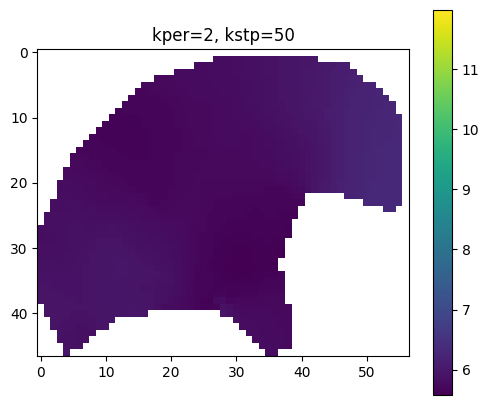

In [12]:
kper = 2

fig, ax = plt.subplots(figsize=(6, 5))
vmin = min(np.nanmin(arrs[(kper, i)]['mean']) for i in range(1, nstp.max()))
vmax = max(np.nanmax(arrs[(kper, i)]['mean']) for i in range(1, nstp.max()))
im = ax.imshow(arrs[(kper, 1)]['mean'], cmap='viridis', vmin=vmin, vmax=vmax)
cb = plt.colorbar(im, ax=ax)
ax.set_title(f'kper={kper}, kstp=1')

def update(frame):
    arr = arrs[(kper, frame)]['mean']
    im.set_data(arr)
    ax.set_title(f'kper={kper}, kstp={frame}')
    return [im]

ani = animation.FuncAnimation(
    fig, update, frames=range(1, nstp.max()), interval=200, blit=True
)

ani.save(f'{kper}_animation.gif', writer='pillow', fps=5)

## Budget

### Prep

In [37]:
extract_kper = lambda x: int([s for s in x.split('_') if s.startswith('kper:')][0].split(':')[1])
extract_kstp = lambda x: int([s for s in x.split('_') if s.startswith('kstp:')][0].split(':')[1])
extract_i = lambda x: int([s for s in x.split('_') if s.startswith('i:')][0].split(':')[1])
extract_j = lambda x: int([s for s in x.split('_') if s.startswith('j:')][0].split(':')[1])
extract_time = lambda x: int([s for s in x.split('_') if s.startswith('time:')][0].split(':')[1])
extract_usecol = lambda x: [s for s in x.split('_') if s.startswith('usecol:')][0].split(':')[1]

In [ ]:
# Decide which columns you want to load
desired_cols = [col for col in headers if col.startswith('oname:budget')]

# data
pre_oe_budget = pd.read_csv(pr_oe_fn, usecols=desired_cols)
budget_noise = pd.read_csv(noise_fn, usecols=desired_cols)

### Diagnostics

In [84]:
budget_noise.head()

,oname:budget_otype:lst_usecol:awanui_kper:1,oname:budget_otype:lst_usecol:awanui_kper:2,oname:budget_otype:lst_usecol:awanui_kper:3,oname:budget_otype:lst_usecol:awanui_kper:4,oname:budget_otype:lst_usecol:confined_kper:1,oname:budget_otype:lst_usecol:confined_kper:2,oname:budget_otype:lst_usecol:confined_kper:3,oname:budget_otype:lst_usecol:confined_kper:4,oname:budget_otype:lst_usecol:inout_kper:1,oname:budget_otype:lst_usecol:inout_kper:2,...,oname:budget_otype:lst_usecol:spring_kper:3,oname:budget_otype:lst_usecol:spring_kper:4,oname:budget_otype:lst_usecol:stoss_kper:1,oname:budget_otype:lst_usecol:stoss_kper:2,oname:budget_otype:lst_usecol:stoss_kper:3,oname:budget_otype:lst_usecol:stoss_kper:4,oname:budget_otype:lst_usecol:total_kper:1,oname:budget_otype:lst_usecol:total_kper:2,oname:budget_otype:lst_usecol:total_kper:3,oname:budget_otype:lst_usecol:total_kper:4
0,-731.623,-969.417,-167.372,-302.193,-471.286,-12305.7,-1210.37,-13204.9,-0.6495,0.2197,...,0,0,0,12406.4,0,12436,-0.649536,0.219727,2.95129,0.279297
1,-731.623,-969.417,-167.372,-302.193,-471.286,-12305.7,-1210.37,-13204.9,-0.6495,0.2197,...,0,0,0,12406.4,0,12436,-0.649536,0.219727,2.95129,0.279297
2,-731.623,-969.417,-167.372,-302.193,-471.286,-12305.7,-1210.37,-13204.9,-0.6495,0.2197,...,0,0,0,12406.4,0,12436,-0.649536,0.219727,2.95129,0.279297
3,-731.623,-969.417,-167.372,-302.193,-471.286,-12305.7,-1210.37,-13204.9,-0.6495,0.2197,...,0,0,0,12406.4,0,12436,-0.649536,0.219727,2.95129,0.279297
4,-731.623,-969.417,-167.372,-302.193,-471.286,-12305.7,-1210.37,-13204.9,-0.6495,0.2197,...,0,0,0,12406.4,0,12436,-0.649536,0.219727,2.95129,0.279297


Text(0.5, 1.0, 'oname:budget_otype:lst_usecol:awanui_kper:1')

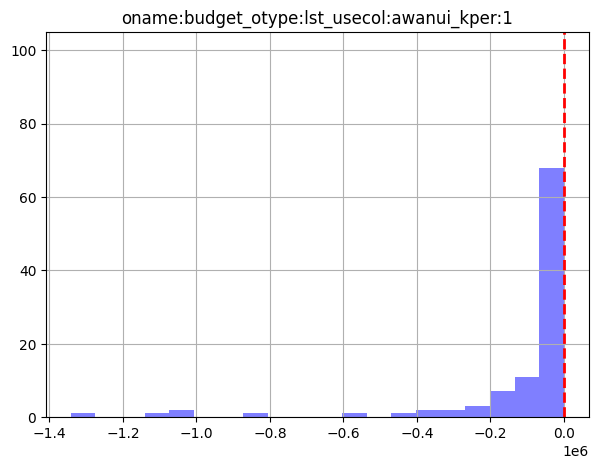

In [95]:
kper = 1
col = 'awanui'
col = f'oname:budget_otype:lst_usecol:{col}_kper:{kper}'
bins=20
fig, ax = plt.subplots(1,1,figsize=(7,5))

# plot posterior/noise (red)
budget_noise.loc[:,col].hist(ax=ax, fc="r", alpha=0.5, bins=bins, label="Noise")

# plot prior (blue)
pre_oe_budget.loc[:,col].hist(ax=ax, fc="blue", alpha=0.5, bins=bins, label="Prior")

# add mean line for noise & prior
meanp_val = pre_oe_budget.loc[:,col].mean()
# ax.axvline(meanp_val, color="blue", linestyle="--", linewidth=2, label=f"Mean={meanp_val:.2f}")
mean_val = budget_noise.loc[:,col].mean()
ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean={mean_val:.2f}")

ax.set_title(col)

### Boxplots

In [38]:
def format_bgtdf(df):
    tdf = df.transpose()
    tdf['kper'] = tdf.index.map(extract_kper)
    tdf['usecol'] = tdf.index.map(extract_usecol)
    return tdf

budget_df = format_bgtdf(pre_oe_budget)

In [66]:
budget_df.head()

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,kper,usecol
oname:budget_otype:lst_usecol:awanui_kper:1,-1024300.0,-18094.70,-55164.9000,-1333.3100,-19089.50,-44172.0,-121400.0,-14237.9000,-0.588700,-1425.690,...,-47455.90,-26052.30,-1341730.0,-57057.70,-1.137400e+06,-4418.370,-20345.40,-731.623,1,awanui
oname:budget_otype:lst_usecol:awanui_kper:2,-11780.8,-34114.10,-160.3030,-0.1028,-40842.60,-22302.0,-73277.4,-5.1414,-0.046148,-545.091,...,-3197.29,-12172.10,-898789.0,-2247.31,-1.130130e+02,-918.162,-5773.02,-969.417,2,awanui
oname:budget_otype:lst_usecol:awanui_kper:3,-275680.0,-6290.53,-5523.4800,-890.4310,-3613.04,-41410.3,-112118.0,-495.2520,-0.156000,-802.281,...,-15749.90,-4165.64,-1818330.0,-32344.60,-4.031400e+04,-3335.460,-3675.52,-167.372,3,awanui
oname:budget_otype:lst_usecol:awanui_kper:4,-10826.2,-15510.20,-14.4612,-0.1521,-8891.13,-23641.6,-72948.9,-1.0438,-0.024713,-592.636,...,-1667.03,-2535.66,-1328980.0,-2551.77,-5.944600e+00,-942.087,-1399.91,-302.193,4,awanui
oname:budget_otype:lst_usecol:confined_kper:1,1008250.0,2175.08,105867.0000,17138.9000,20466.20,18892.3,30198.7,36701.5000,6275.600000,1957.020,...,41273.20,-53264.70,193534.0,56108.20,1.467230e+06,3242.520,16317.20,-471.286,1,confined


In [71]:
budget_df.melt(
    id_vars=['usecol', 'kper'],
    )

,usecol,kper,variable,value
0,awanui,1,0,-1.024300e+06
1,awanui,2,0,-1.178080e+04
2,awanui,3,0,-2.756800e+05
3,awanui,4,0,-1.082620e+04
4,confined,1,0,1.008250e+06
...,...,...,...,...
3595,stoss,4,99,1.243600e+04
3596,total,1,99,-6.495360e-01
3597,total,2,99,2.197270e-01
3598,total,3,99,2.951290e+00


c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.


<Axes: xlabel='usecol', ylabel='value'>

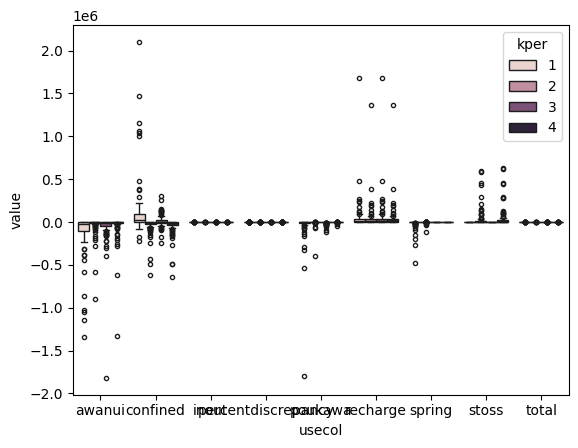

In [79]:
import seaborn as sns

bx_df = budget_df.melt(
    id_vars=['usecol', 'kper'],
    )

sns.boxplot(
    data = bx_df,
    x='usecol',
    y='value',
    hue='kper',
    fliersize=3
    # log_scale=True
)

In [63]:
budget_df.melt()

,variable,value
0,0,-1024300.0
1,0,-11780.8
2,0,-275680.0
3,0,-10826.2
4,0,1008250.0
...,...,...
3667,usecol,stoss
3668,usecol,total
3669,usecol,total
3670,usecol,total


C:\Users\tfo46\AppData\Local\Temp\ipykernel_600\2892174719.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


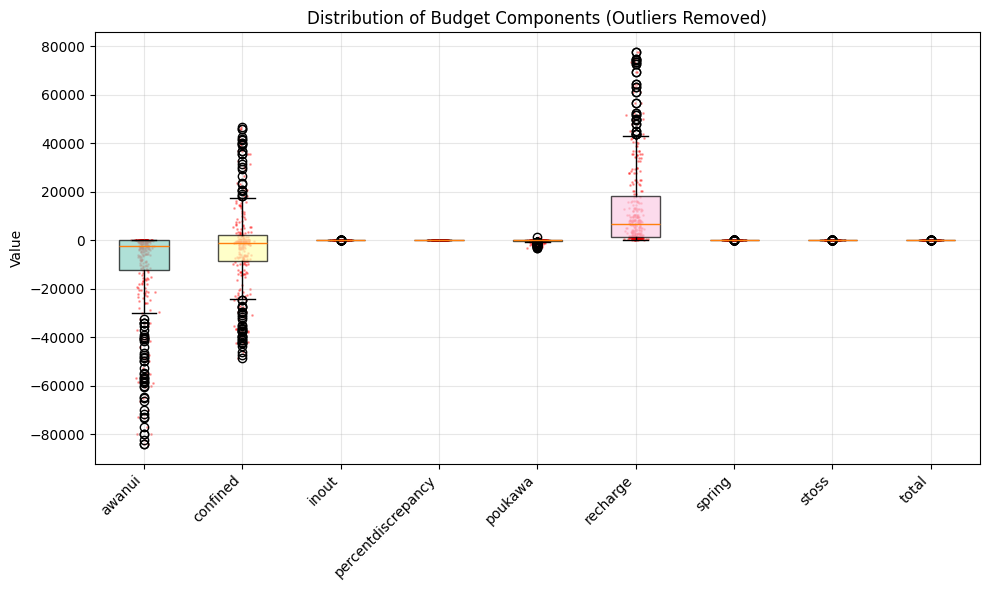

Outlier removal summary:
awanui: 59 outliers removed (14.8%)
confined: 104 outliers removed (26.0%)
inout: 69 outliers removed (17.2%)
percentdiscrepancy: 158 outliers removed (39.5%)
poukawa: 78 outliers removed (19.5%)
recharge: 40 outliers removed (10.0%)
spring: 87 outliers removed (21.8%)
stoss: 97 outliers removed (24.2%)
total: 69 outliers removed (17.2%)


In [57]:
# Create a single boxplot with all usecols on the same plot (outliers removed)
unique_usecols = budget_df['usecol'].unique()

# Prepare data for boxplot - separate list for each usecol with outlier removal
boxplot_data = []
labels = []

def remove_outliers(data, method='iqr'):
    """Remove outliers using IQR method"""
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return data[(data >= lower_bound) & (data <= upper_bound)]

for usecol in unique_usecols:
    df_sub = budget_df[budget_df['usecol'] == usecol]
    value_cols = [col for col in df_sub.columns if col not in ['kper', 'usecol']]
    
    # Combine all values for this usecol
    all_values = []
    for col in value_cols:
        values = df_sub[col].dropna().values
        all_values.extend(values)
    
    # Remove outliers
    all_values = np.array(all_values)
    filtered_values = remove_outliers(all_values)
    
    boxplot_data.append(filtered_values)
    labels.append(usecol)

# Create the boxplot
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True)

# Color the boxes
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_usecols)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add individual points with jitter for each category
np.random.seed(42)  # For reproducible jitter
for i, values in enumerate(boxplot_data):
    x_pos = np.random.normal(i+1, 0.04, size=len(values))  # Add jitter around position i+1
    ax.scatter(x_pos, values, alpha=0.3, s=1, color='red')

ax.set_ylabel('Value')
ax.set_title('Distribution of Budget Components (Outliers Removed)')
ax.grid(True, alpha=0.3)

# Rotate x-axis labels if they're long
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary of outlier removal
print("Outlier removal summary:")
for i, usecol in enumerate(unique_usecols):
    original_count = len(np.concatenate([df_sub[col].dropna().values 
                                       for col in df_sub.columns 
                                       if col not in ['kper', 'usecol']
                                       for df_sub in [budget_df[budget_df['usecol'] == usecol]]]))
    filtered_count = len(boxplot_data[i])
    removed_count = original_count - filtered_count
    print(f"{usecol}: {removed_count} outliers removed ({removed_count/original_count*100:.1f}%)")

## Timeseries (heads)

### Prep

In [ ]:
extract_i = lambda x: int([s for s in x.split('_') if s.startswith('i:')][0].split(':')[1])
extract_j = lambda x: int([s for s in x.split('_') if s.startswith('j:')][0].split(':')[1])
extract_time = lambda x: int([s for s in x.split('_') if s.startswith('time:')][0].split(':')[1])
extract_usecol = lambda x: [s for s in x.split('_') if s.startswith('usecol:')][0].split(':')[1]

# Decide which columns you want to load
desired_cols = [col for col in headers if col.startswith('oname:ts-heads')]

# data
pre_oe_ts = pd.read_csv(pr_oe_fn, usecols=desired_cols)
ts_noise = pd.read_csv(noise_fn, usecols=desired_cols)

### Diagnostics

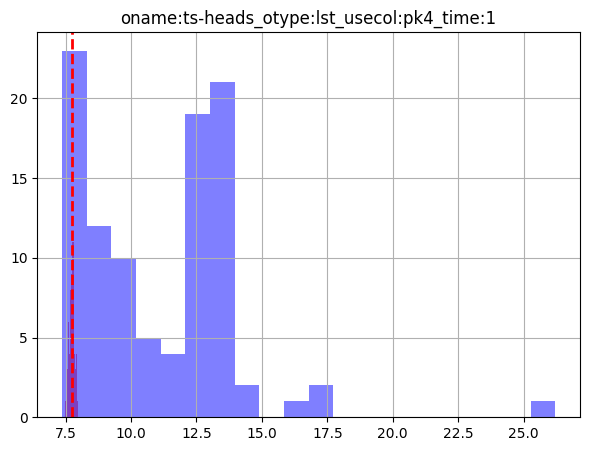

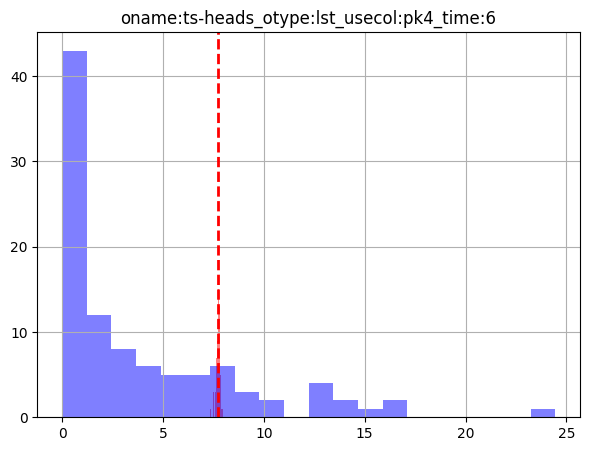

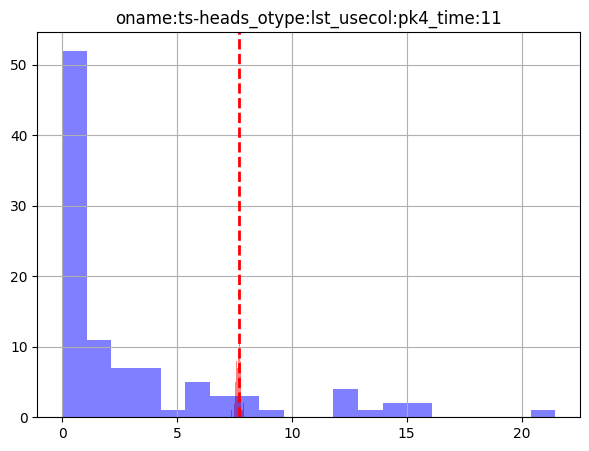

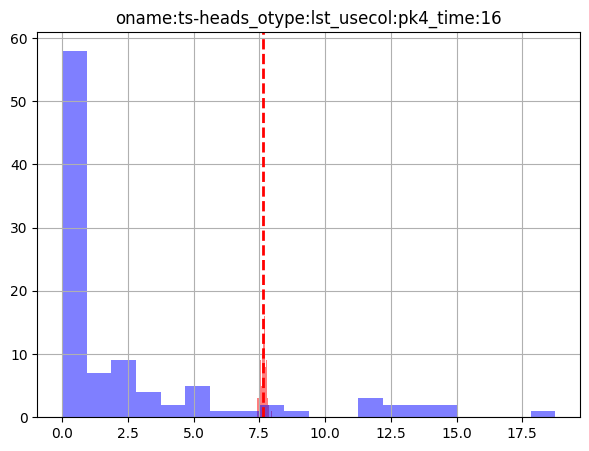

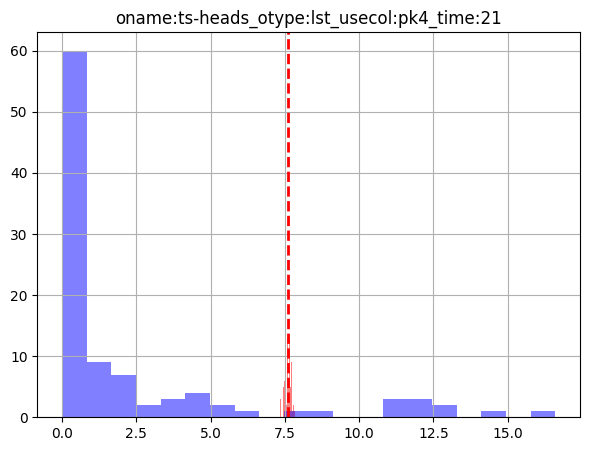

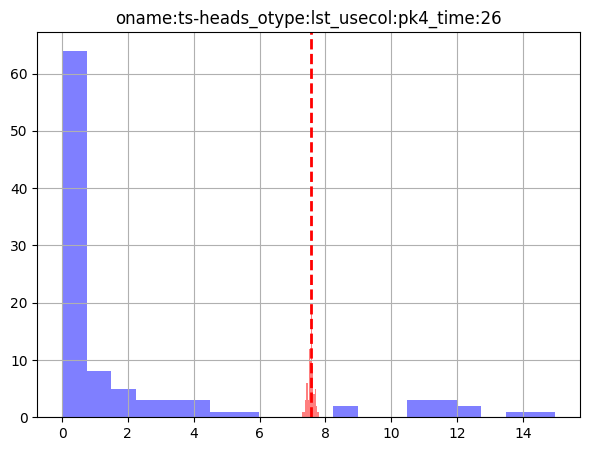

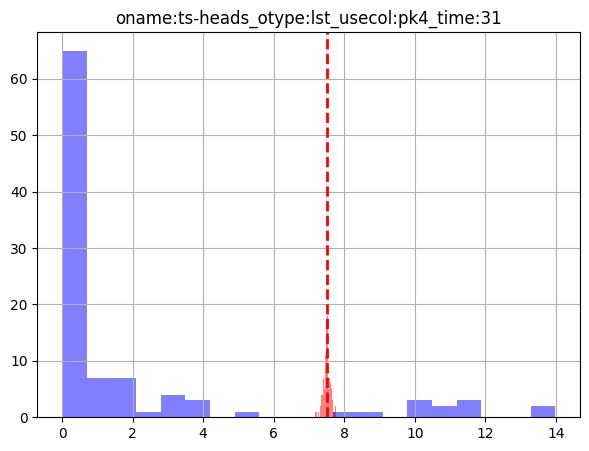

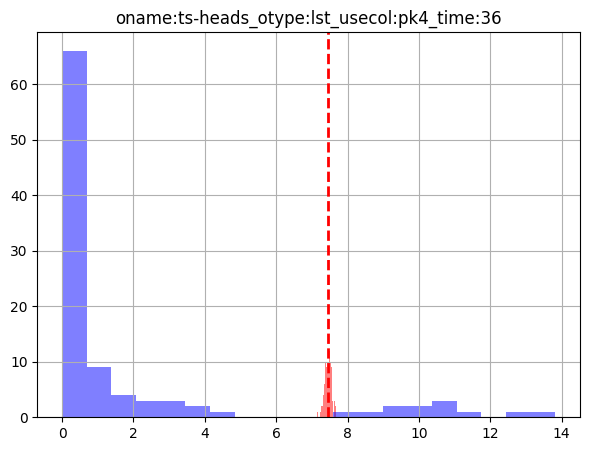

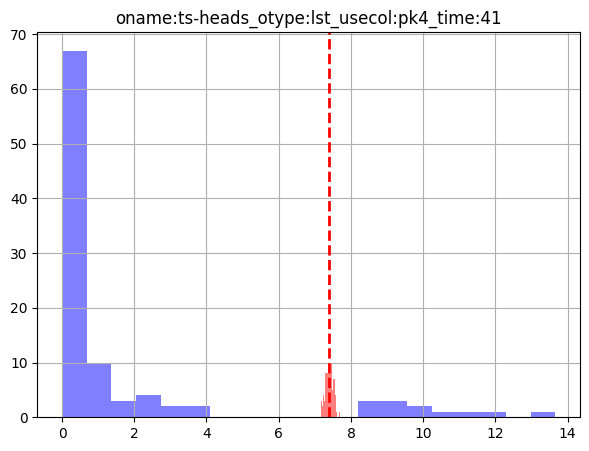

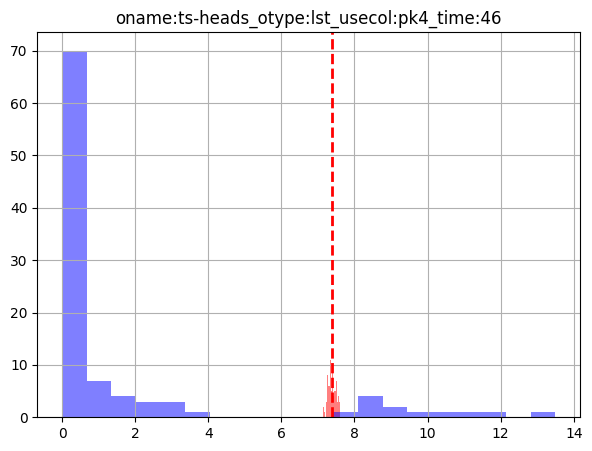

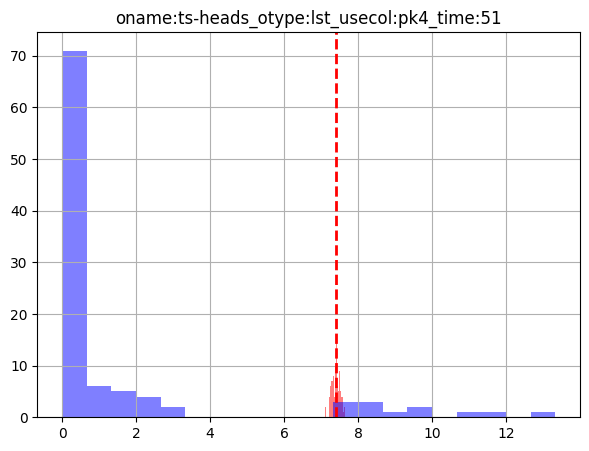

In [105]:
time = 1
colname = 'pk4'

for time in np.arange(1, 53, 5):
    col = f'oname:ts-heads_otype:lst_usecol:{colname}_time:{time}'
    bins=20
    fig, ax = plt.subplots(1,1,figsize=(7,5))

    # plot posterior/noise (red)
    ts_noise.loc[:,col].hist(ax=ax, fc="r", alpha=0.5, bins=bins, label="Noise")

    # plot prior (blue)
    pre_oe_ts.loc[:,col].hist(ax=ax, fc="blue", alpha=0.5, bins=bins, label="Prior")

    # add mean line for noise & prior
    meanp_val = pre_oe_ts.loc[:,col].mean()
    # ax.axvline(meanp_val, color="blue", linestyle="--", linewidth=2, label=f"Mean={meanp_val:.2f}")
    mean_val = ts_noise.loc[:,col].mean()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean={mean_val:.2f}")

    ax.set_title(col)

### Plots

In [47]:
pre_oe_ts.transpose()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:1,-5.812010,-0.769659,-1.483860,-0.833812,-1.27167,-6.309280,-6.499680,-1.233240,-2.843230,-5.129350,...,-0.210562,-0.479831,-4.57303,3.56583,-4.21393,-5.742110,-1.606860,-6.467670,-6.320560,-0.151822
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:10,-13.529800,-0.814745,-13.460800,-13.558800,-1.47866,-13.342900,-13.200900,-13.546700,-12.813600,-10.247000,...,-13.240000,-13.542000,-9.95039,2.30342,-10.61810,-7.151470,-13.130000,-13.517600,-13.536300,-0.954253
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:100,-13.014300,0.046704,-13.039400,-13.058900,-2.29374,-12.956500,-13.060000,-13.045500,-12.690800,-12.462900,...,-12.738300,-13.042000,-12.02290,-2.16742,-11.80220,-12.142800,-13.059300,-13.049900,-12.276500,-3.898990
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:101,-12.995900,0.029679,-13.021000,-13.040500,-2.32454,-12.938100,-13.041600,-13.027100,-12.672400,-12.455000,...,-12.719900,-13.023600,-12.02650,-2.25966,-11.78380,-12.164700,-13.040900,-13.031600,-12.278000,-3.968230
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:102,-12.977500,0.012764,-13.002600,-13.022100,-2.35511,-12.919800,-13.023200,-13.008800,-12.654000,-12.446200,...,-12.701500,-13.005200,-12.02860,-2.34899,-11.76540,-12.184600,-13.022500,-13.013200,-12.278300,-4.036560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oname:ts-heads_otype:lst_usecol:pk4_time:95,0.046056,13.285800,0.020970,0.001447,11.01610,0.103814,0.000318,0.014812,0.369653,0.667195,...,0.322075,0.018376,1.17477,11.49390,1.25814,1.151020,0.001043,0.010726,0.903636,9.613530
oname:ts-heads_otype:lst_usecol:pk4_time:96,0.046056,13.249800,0.020970,0.001447,10.96570,0.103812,0.000318,0.014812,0.369616,0.650595,...,0.322075,0.018376,1.14317,11.36690,1.25814,1.099690,0.001042,0.010660,0.876555,9.521190
oname:ts-heads_otype:lst_usecol:pk4_time:97,0.046056,13.214000,0.020969,0.001447,10.91560,0.103812,0.000318,0.014812,0.369619,0.635443,...,0.322075,0.018376,1.11379,11.24350,1.25814,1.050800,0.001041,0.010637,0.851094,9.429820
oname:ts-heads_otype:lst_usecol:pk4_time:98,0.046056,13.178200,0.020969,0.001447,10.86570,0.103811,0.000318,0.014812,0.369594,0.621611,...,0.322075,0.018376,1.08646,11.12340,1.25814,1.004230,0.001040,0.010555,0.827316,9.339390


In [48]:
def format_tsdf(df):
    tdf = df.transpose()
    tdf['time'] = tdf.index.map(extract_time)
    tdf['usecol'] = tdf.index.map(extract_usecol)
    return tdf

ts_df = format_tsdf(pre_oe_ts)

In [49]:
ts_df

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,time,usecol
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:1,-5.812010,-0.769659,-1.483860,-0.833812,-1.27167,-6.309280,-6.499680,-1.233240,-2.843230,-5.129350,...,-4.57303,3.56583,-4.21393,-5.742110,-1.606860,-6.467670,-6.320560,-0.151822,1,pk4-conf-diff
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:10,-13.529800,-0.814745,-13.460800,-13.558800,-1.47866,-13.342900,-13.200900,-13.546700,-12.813600,-10.247000,...,-9.95039,2.30342,-10.61810,-7.151470,-13.130000,-13.517600,-13.536300,-0.954253,10,pk4-conf-diff
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:100,-13.014300,0.046704,-13.039400,-13.058900,-2.29374,-12.956500,-13.060000,-13.045500,-12.690800,-12.462900,...,-12.02290,-2.16742,-11.80220,-12.142800,-13.059300,-13.049900,-12.276500,-3.898990,100,pk4-conf-diff
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:101,-12.995900,0.029679,-13.021000,-13.040500,-2.32454,-12.938100,-13.041600,-13.027100,-12.672400,-12.455000,...,-12.02650,-2.25966,-11.78380,-12.164700,-13.040900,-13.031600,-12.278000,-3.968230,101,pk4-conf-diff
oname:ts-heads_otype:lst_usecol:pk4-conf-diff_time:102,-12.977500,0.012764,-13.002600,-13.022100,-2.35511,-12.919800,-13.023200,-13.008800,-12.654000,-12.446200,...,-12.02860,-2.34899,-11.76540,-12.184600,-13.022500,-13.013200,-12.278300,-4.036560,102,pk4-conf-diff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oname:ts-heads_otype:lst_usecol:pk4_time:95,0.046056,13.285800,0.020970,0.001447,11.01610,0.103814,0.000318,0.014812,0.369653,0.667195,...,1.17477,11.49390,1.25814,1.151020,0.001043,0.010726,0.903636,9.613530,95,pk4
oname:ts-heads_otype:lst_usecol:pk4_time:96,0.046056,13.249800,0.020970,0.001447,10.96570,0.103812,0.000318,0.014812,0.369616,0.650595,...,1.14317,11.36690,1.25814,1.099690,0.001042,0.010660,0.876555,9.521190,96,pk4
oname:ts-heads_otype:lst_usecol:pk4_time:97,0.046056,13.214000,0.020969,0.001447,10.91560,0.103812,0.000318,0.014812,0.369619,0.635443,...,1.11379,11.24350,1.25814,1.050800,0.001041,0.010637,0.851094,9.429820,97,pk4
oname:ts-heads_otype:lst_usecol:pk4_time:98,0.046056,13.178200,0.020969,0.001447,10.86570,0.103811,0.000318,0.014812,0.369594,0.621611,...,1.08646,11.12340,1.25814,1.004230,0.001040,0.010555,0.827316,9.339390,98,pk4


In [50]:
ts_df['usecol'].unique()

array(['pk4-conf-diff', 'pk4-spr-diff', 'pk4'], dtype=object)

### Timeseries (1st-99th)

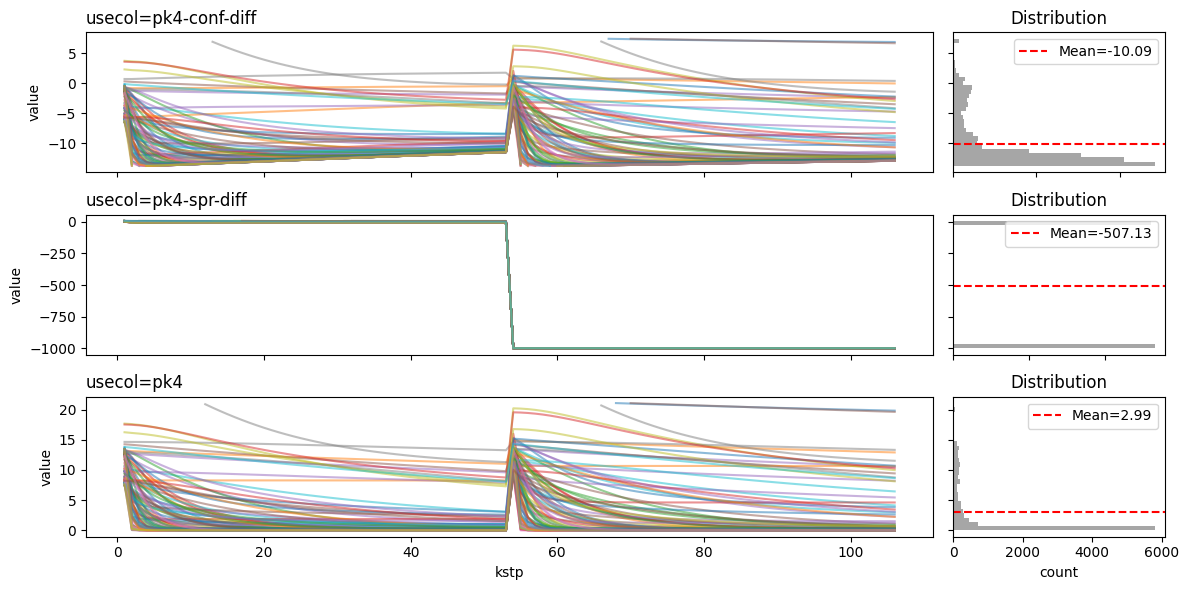

In [51]:
unique_usecols = ts_df['usecol'].unique()
n = len(unique_usecols)

fig = plt.figure(figsize=(12, n * 2))
gs = gridspec.GridSpec(n, 2, width_ratios=[4, 1])

axes = []
for i in range(n):
    if i == 0:
        ax0 = fig.add_subplot(gs[i, 0])
        ax1 = fig.add_subplot(gs[i, 1], sharey=ax0)
    else:
        ax0 = fig.add_subplot(gs[i, 0], sharex=axes[0][0])
        ax1 = fig.add_subplot(gs[i, 1], sharey=ax0)
    axes.append([ax0, ax1])

for idx, usecol in enumerate(unique_usecols):
    df_sub = ts_df[(ts_df['usecol'] == usecol)].sort_values('time')
    value_cols = [col for col in df_sub.columns if col not in ['time', 'usecol']]
    all_values = df_sub[value_cols].values.flatten()
    lower, upper = np.percentile(all_values, [1, 99])
    for col in value_cols:
        y = df_sub[col].copy()
        y[(y < lower) | (y > upper)] = np.nan
        axes[idx][0].plot(df_sub['time'], y, alpha=0.5)
    axes[idx][0].set_title(f'usecol={usecol}', loc='left')
    axes[idx][0].set_ylabel('value')
    # Only show x-axis on the bottom plot
    if idx != n - 1:
        axes[idx][0].set_xlabel('')
        axes[idx][0].tick_params(labelbottom=False)
    else:
        axes[idx][0].set_xlabel('kstp')
    filtered_values = all_values[(all_values >= lower) & (all_values <= upper)]
    axes[idx][1].hist(filtered_values, bins=30, alpha=0.7, color='gray', orientation='horizontal')
    mean_val = filtered_values.mean()
    axes[idx][1].axhline(mean_val, color='red', linestyle='--', label=f'Mean={mean_val:.2f}')
    axes[idx][1].set_title(f'Distribution')
    axes[idx][1].tick_params(labelleft=False)
    # Only show x-axis on the bottom plot
    if idx != n - 1:
        axes[idx][1].set_xlabel('')
        axes[idx][1].tick_params(labelbottom=False)
    else:
        axes[idx][1].set_xlabel('count')
    axes[idx][1].legend()

plt.tight_layout()
plt.show()

### Awanui Flux vs PK4 Head 

In [52]:
idf = ts_df[
    (ts_df['kper'] == 1) \
        & (ts_df['kstp'] == 1)
    ].sort_values('kstp')
col_df = idf.set_index('usecol').transpose()[:-2]

KeyError: 'kper'

In [102]:
col_df.columns

Index(['awcum', 'awgwhead', 'awq', 'awswgwdiff', 'awswhead', 'awtot',
       'confhead', 'firstnegday', 'pk4awgwdiff', 'pk4awswdiff', 'pk4confdiff',
       'pk4head', 'pk4pwgwdiff', 'pk4pwswdiff', 'pk4springdiff', 'pwcum',
       'pwgwhead', 'pwq', 'pwswgwdiff', 'pwswhead', 'pwtot', 'springcum',
       'springhead', 'springq'],
      dtype='object', name='usecol')

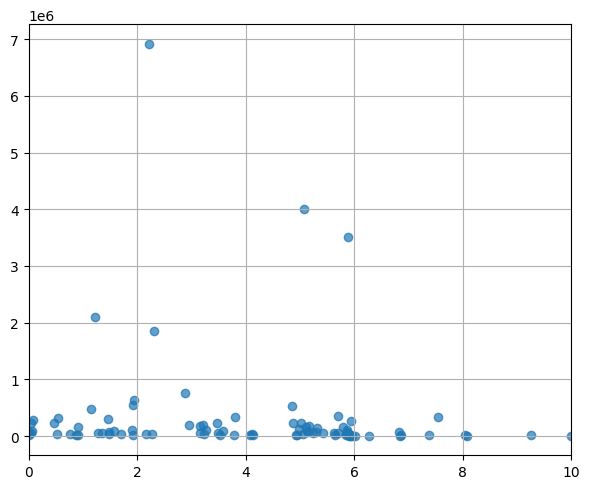

In [109]:
# Example: scatter plot of the first two columns in col_df
col_names = col_df.columns[:2]
plt.figure(figsize=(6, 5))
plt.scatter(col_df['pk4springdiff'], col_df['awtot']*-1, alpha=0.7)
plt.xlim(0,10)
# plt.ylim(-250,5)
plt.tight_layout()
plt.grid()
plt.show()

In [111]:
idf = ts_df[
    (ts_df['kper'] == 2) \
        # & (ts_df['kstp'] == 1)
    ].sort_values('kstp')
# col_df = idf.set_index('usecol').transpose()

In [112]:
idf

,0,1,2,3,4,5,6,7,8,9,...,93,94,95,96,97,98,99,kper,kstp,usecol
oname:timeseries_otype:lst_usecol:awcum_kper:2_kstp:1,-1.293550,-978.099000,-1.012570e+06,-63418.900000,-4368.160000,-6.340010,-805.55300,-17683.800000,-4862.280000,-274.06600,...,-33.59480,-6468.42000,-105.059000,-16.979100,-233.55400,-3.536430,-1660.40000,2,1,awcum
oname:timeseries_otype:lst_usecol:awgwhead_kper:2_kstp:1,10.474700,0.095069,1.324580e+00,1.940700,3.780560,7.120300,11.07160,0.122775,0.672726,11.27250,...,10.58750,6.95799,0.808224,0.000158,12.92110,0.744205,13.72630,2,1,awgwhead
oname:timeseries_otype:lst_usecol:springq_kper:2_kstp:1,-222.231000,-0.009939,-5.362380e+03,-21.751400,-0.049880,-15766.300000,-1.22625,-0.052209,-489.582000,-0.05281,...,-4.40266,-3.75349,-0.000506,-0.005282,-132.33100,-0.003670,-13.74300,2,1,springq
oname:timeseries_otype:lst_usecol:springcum_kper:2_kstp:1,-858.969000,-0.179910,-6.014760e+05,-376.032000,-0.514329,-72053.900000,-1202.98000,-1.397330,-6261.390000,-2.00784,...,-343.47600,-67.77720,-4.895820,-0.012125,-1076.91000,-0.588835,-164.83500,2,1,springcum
oname:timeseries_otype:lst_usecol:springhead_kper:2_kstp:1,7.593460,7.593460,7.593460e+00,7.593460,7.593460,7.593460,7.59346,7.593460,7.593460,7.59346,...,7.59346,7.59346,7.593460,7.593460,7.59346,7.593460,7.59346,2,1,springhead
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oname:timeseries_otype:lst_usecol:pwtot_kper:2_kstp:51,-4055.390000,-1894.770000,-2.041010e+03,-1893.610000,-1916.460000,-1910.680000,-2777.42000,-2048.040000,-2076.820000,-15671.00000,...,-15505.40000,-2127.57000,-1915.540000,-1902.740000,-21768.60000,-1893.550000,-2096.60000,2,51,pwtot
oname:timeseries_otype:lst_usecol:awcum_kper:2_kstp:51,-0.624075,-21.914300,-2.242470e+03,-179.515000,-22.075600,-1.258800,-15.45050,-883.706000,-520.948000,-76.51300,...,-1.18165,-686.40400,-0.200835,-0.037006,-81.78840,-0.370422,-980.36500,2,51,awcum
oname:timeseries_otype:lst_usecol:pwcum_kper:2_kstp:51,-2161.920000,-1.298970,-1.475420e+02,-0.143050,-22.987900,-17.215300,-883.95000,-154.575000,-183.357000,-13777.50000,...,-13612.00000,-234.10100,-22.070300,-9.273770,-19875.10000,-0.080918,-203.12800,2,51,pwcum
oname:timeseries_otype:lst_usecol:firstnegday_kper:2_kstp:51,2.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,4.00000,1.000000,1.000000,8.00000,...,4.00000,1.00000,1.000000,1.000000,19.00000,1.000000,-1.00000,2,51,firstnegday


### All plots

In [124]:
dfs = {}
for i in idf['kstp'].unique():
    kstp_df = idf[idf['kstp'] == i]
    dfs[i] = kstp_df.set_index('usecol').transpose()[:-2]

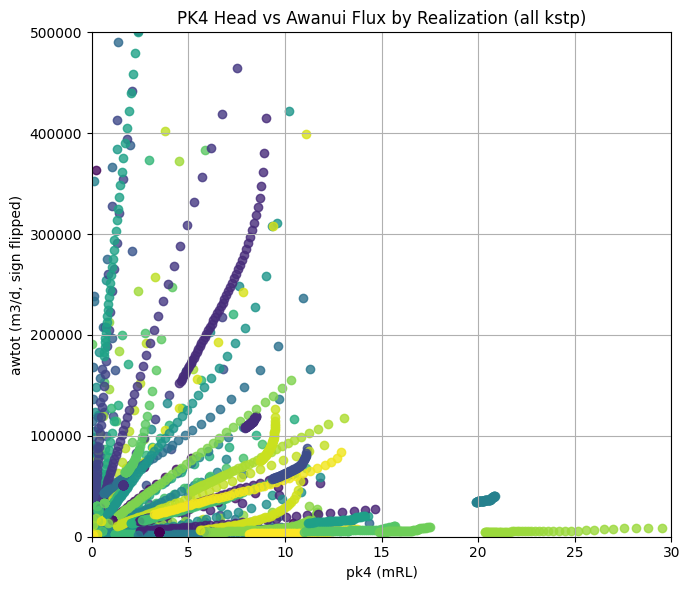

In [134]:
plt.figure(figsize=(7, 6))

# Use realization index for color, all points have the same marker shape
for nstp in dfs.keys():
    ndf = dfs[nstp]
    colors = plt.cm.viridis(np.linspace(0, 1, len(ndf)))
    for i, (idx, row) in enumerate(ndf.iterrows()):
        plt.scatter(row['pk4head'], -row['awtot'],
                    color=colors[i],
                    marker='o',  # same shape for all
                    alpha=0.8)

plt.xlabel('pk4 (mRL)')
plt.ylabel('awtot (m3/d, sign flipped)')
plt.title('PK4 Head vs Awanui Flux by Realization (all kstp)')
plt.xlim(0, 30)
plt.ylim(0, 500000) 
plt.tight_layout()
plt.grid()
plt.show()

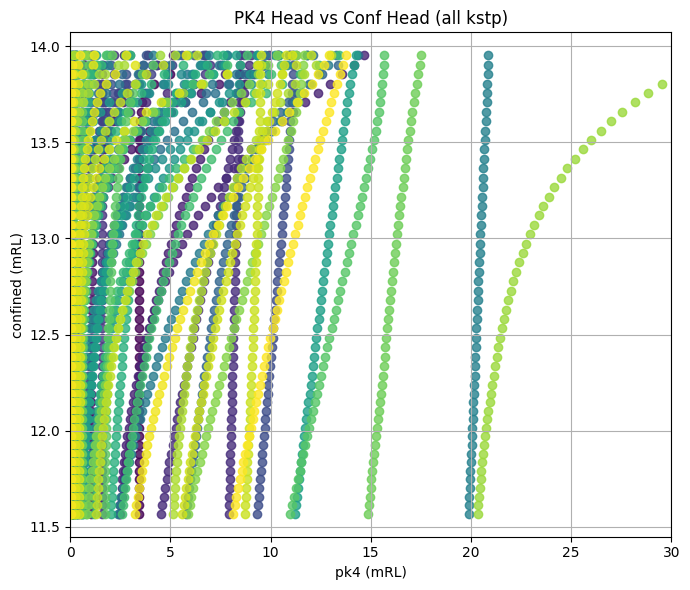

In [157]:
plt.figure(figsize=(7, 6))

# Use realization index for color, all points have the same marker shape
for nstp in dfs.keys():
    ndf = dfs[nstp]
    colors = plt.cm.viridis(np.linspace(0, 1, len(ndf)))
    for i, (idx, row) in enumerate(ndf.iterrows()):
        plt.scatter(row['pk4head'], row['confhead'],
                    color=colors[i],
                    marker='o',  # same shape for all
                    alpha=0.8)

plt.xlabel('pk4 (mRL)')
plt.ylabel('confined (mRL)')
plt.title('PK4 Head vs Conf Head (all kstp)')
plt.xlim(0, 30)
# plt.ylim(0, 500000) 
plt.tight_layout()
plt.grid()
plt.show()

## Timeseries (Awanui Q)

### Prep

In [107]:
extract_kper = lambda x: int([s for s in x.split('_') if s.startswith('kper:')][0].split(':')[1])
extract_kstp = lambda x: int([s for s in x.split('_') if s.startswith('kstp:')][0].split(':')[1])
extract_i = lambda x: int([s for s in x.split('_') if s.startswith('i:')][0].split(':')[1])
extract_j = lambda x: int([s for s in x.split('_') if s.startswith('j:')][0].split(':')[1])
extract_time = lambda x: int([s for s in x.split('_') if s.startswith('time:')][0].split(':')[1])
extract_usecol = lambda x: [s for s in x.split('_') if s.startswith('usecol:')][0].split(':')[1]

# Decide which columns you want to load
desired_cols = [col for col in headers if col.startswith('oname:awq')]

# data
pre_oe_ts = pd.read_csv(pr_oe_fn, usecols=desired_cols)
ts_noise = pd.read_csv(noise_fn, usecols=desired_cols)

In [108]:
desired_cols[:10]

['oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:10_j:42',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:10_j:50',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:10_j:51',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:11_j:42',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:11_j:48',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:11_j:49',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:12_j:42',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:12_j:46',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:12_j:47',
 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:12_j:9']

### Diagnostics

Text(0.5, 1.0, 'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:10_j:42')

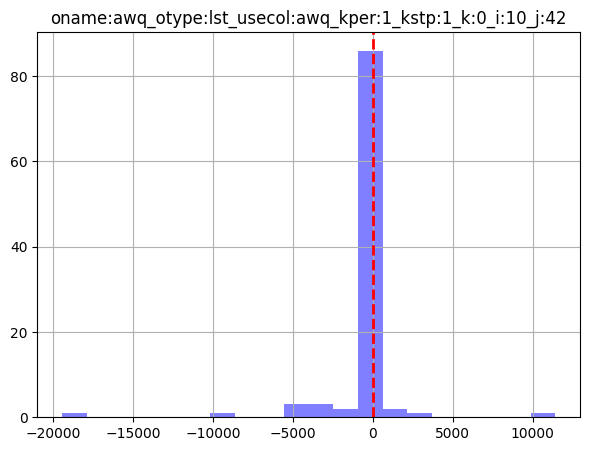

In [109]:
col = f'oname:awq_otype:lst_usecol:awq_kper:1_kstp:1_k:0_i:10_j:42'
bins=20
fig, ax = plt.subplots(1,1,figsize=(7,5))

# plot posterior/noise (red)
ts_noise.loc[:,col].hist(ax=ax, fc="r", alpha=0.5, bins=bins, label="Noise")

# plot prior (blue)
pre_oe_ts.loc[:,col].hist(ax=ax, fc="blue", alpha=0.5, bins=bins, label="Prior")

# add mean line for noise & prior
meanp_val = pre_oe_ts.loc[:,col].mean()
# ax.axvline(meanp_val, color="blue", linestyle="--", linewidth=2, label=f"Mean={meanp_val:.2f}")
mean_val = ts_noise.loc[:,col].mean()
ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean={mean_val:.2f}")

ax.set_title(col)

## Params

params_headers

In [156]:
[col for col in params_headers if col.startswith('pname:ghb-conf-cond')]

['pname:ghb-conf-cond-fngr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:1_idx2:27',
 'pname:ghb-conf-cond-fngr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:1_idx2:28',
 'pname:ghb-conf-cond-fngr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:1_idx2:29',
 'pname:ghb-conf-cond-fngr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:1_idx2:30',
 'pname:ghb-conf-cond-fngr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:1_idx2:31',
 'pname:ghb-conf-cond-fngr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:1_idx2:32',
 'pname:ghb-conf-cond-fngr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:1_idx2:33',
 'pname:ghb-conf-cond-fngr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:1_idx2:34',
 'pname:ghb-conf-cond-fngr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:1_idx2:35',
 'pname:ghb-conf-cond-fngr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:1_idx2:36',
 'pname:ghb-conf-cond-fngr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0:0_idx1:1_idx2:37',
 'pname:ghb-conf-cond-fngr_inst:0_ptype:gr_usecol:4_pstyle:m_idx0

In [ ]:
# Decide which columns you want to load
desired_cols = [col for col in headers if col.startswith('pname:ghb-conf')]


In [ ]:

# data
pre_oe_ts = pd.read_csv(pr_oe_fn, usecols=desired_cols)